# Phase 2E — Balanced Sampling: Results Notebook

**Experiment:** Replace focal loss + class weights with `WeightedRandomSampler` + plain `CrossEntropyLoss`.

**Key finding:** R2 sensitivity jumped from 0.583 → **0.917**, but R1 collapsed to **0.000**.
The recommended config (P2B + TTA) remains superior overall.

Sections: Setup · Overall Metrics · Per-Class Metrics · Confusion Matrix · ROC Curves · Sensitivity Comparison · Probability Distributions · Summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 11, 'axes.titlesize': 12,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

TEAL         = '#006B6B'
AMBER        = '#D35400'
CLASS_NAMES  = ['R0', 'R1', 'R2', 'R3A']
CLASS_LABELS = ['R0 (Normal)', 'R1 (Mild/Mod NPDR)', 'R2 (Mod/Sev NPDR)', 'R3A (PDR)']
CLASS_COLORS = ['#1A9E77', '#D95F02', '#7570B3', '#E7298A']
CV_OUTPUT    = Path('output_dir/phase2e_cv')
GRADE        = {'R0': 0, 'R1': 1, 'R2': 2, 'R3A': 3}
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data & Apply Pipeline

In [2]:
df_all  = pd.read_csv('labels/splits.csv')
df_all['grade_int'] = df_all['retinopathy'].map(GRADE)
df_test = df_all[df_all['split'] == 'test'].copy().reset_index(drop=True)

test_codes  = df_test['code'].values
test_labels = df_test['grade_int'].values

# ensemble mean across 5 folds
fold_probs = [np.load(CV_OUTPUT / f'fold_{f}_test_probs.npy').astype(np.float64)
              for f in range(5)]
img_probs = np.mean(fold_probs, axis=0)
img_probs = img_probs / img_probs.sum(axis=1, keepdims=True)

# patient max pooling
records = {}
for c, prob, lbl in zip(test_codes, img_probs, test_labels):
    if c not in records:
        records[c] = {'probs': [], 'worst': 0}
    records[c]['probs'].append(prob)
    records[c]['worst'] = max(records[c]['worst'], int(lbl))

pt_probs, pt_labels = [], []
for c in sorted(records.keys()):
    p = np.stack(records[c]['probs']).max(axis=0)
    p = p / p.sum()
    pt_probs.append(p)
    pt_labels.append(records[c]['worst'])

pt_probs  = np.array(pt_probs)
pt_labels = np.array(pt_labels)
pt_preds  = pt_probs.argmax(axis=1)

print(f'Test patients: {len(pt_labels)}')
vals, cnts = np.unique(pt_labels, return_counts=True)
print('Class distribution:', {CLASS_NAMES[v]: int(c) for v, c in zip(vals, cnts)})

Test patients: 175
Class distribution: {'R0': 91, 'R1': 63, 'R2': 12, 'R3A': 9}


## 2. Overall Metrics

In [3]:
accuracy   = accuracy_score(pt_labels, pt_preds)
kappa      = cohen_kappa_score(pt_labels, pt_preds, weights='quadratic')
auroc      = roc_auc_score(pt_labels, pt_probs, multi_class='ovr', average='macro')
macro_prec = precision_score(pt_labels, pt_preds, average='macro',    zero_division=0)
macro_rec  = recall_score(pt_labels,   pt_preds, average='macro',    zero_division=0)
macro_f1   = f1_score(pt_labels,       pt_preds, average='macro',    zero_division=0)

# P2B+TTA reference (recommended config)
ref = {'accuracy':0.8571,'kappa':0.8220,'auroc':0.9370,
       'macro_prec':0.8524,'macro_rec':0.6999,'macro_f1':0.7475}

print('=' * 58)
print('  P2E vs P2B+TTA  —  Test Set (175 patients)')
print('=' * 58)
print(f'{"Metric":<26} {"P2E":>10} {"P2B+TTA":>10} {"Delta":>8}')
print('-' * 58)
for label, val, ref_val in [
    ('Accuracy',           accuracy,   ref['accuracy']),
    ("Cohen's Kappa",      kappa,      ref['kappa']),
    ('Macro AUROC',        auroc,      ref['auroc']),
    ('Macro Precision',    macro_prec, ref['macro_prec']),
    ('Macro Recall',       macro_rec,  ref['macro_rec']),
    ('Macro F1',           macro_f1,   ref['macro_f1']),
]:
    d = val - ref_val
    flag = '  ▲' if d > 0.005 else ('  ▼' if d < -0.005 else '')
    print(f'{label:<26} {val:>10.4f} {ref_val:>10.4f} {d:>+8.4f}{flag}')
print('=' * 58)

  P2E vs P2B+TTA  —  Test Set (175 patients)
Metric                            P2E    P2B+TTA    Delta
----------------------------------------------------------
Accuracy                       0.6000     0.8571  -0.2571  ▼
Cohen's Kappa                  0.7009     0.8220  -0.1211  ▼
Macro AUROC                    0.7753     0.9370  -0.1617  ▼
Macro Precision                0.3717     0.8524  -0.4807  ▼
Macro Recall                   0.5625     0.6999  -0.1374  ▼
Macro F1                       0.4163     0.7475  -0.3312  ▼


## 3. Per-Class Metrics

In [4]:
cm = confusion_matrix(pt_labels, pt_preds, labels=[0,1,2,3])
pt_labels_bin = label_binarize(pt_labels, classes=[0,1,2,3])

per_class = []
for i in range(4):
    tp = cm[i,i]; fn = cm[i].sum()-tp
    fp = cm[:,i].sum()-tp; tn = cm.sum()-tp-fn-fp
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    ppv  = tp/(tp+fp) if (tp+fp)>0 else 0.0
    npv  = tn/(tn+fn) if (tn+fn)>0 else 0.0
    f1   = 2*ppv*sens/(ppv+sens) if (ppv+sens)>0 else 0.0
    auc_i = roc_auc_score(pt_labels_bin[:,i], pt_probs[:,i])
    per_class.append({'Class': CLASS_LABELS[i], 'N': int(cm[i].sum()),
                      'Sensitivity': sens, 'Specificity': spec,
                      'Precision': ppv, 'NPV': npv,
                      'F1': f1, 'AUROC': auc_i})

# P2B+TTA reference per-class
ref_sens = [0.9780, 0.7937, 0.5833, 0.4444]
ref_spec = [0.8690, 0.9018, 0.9816, 1.0000]

df_pc = pd.DataFrame(per_class).set_index('Class')
print(df_pc[['N','Sensitivity','Specificity','Precision','NPV','F1','AUROC']]
      .to_string(float_format='{:.4f}'.format))
print()
print('Sensitivity vs P2B+TTA reference:')
for i, cl in enumerate(CLASS_LABELS):
    s = per_class[i]['Sensitivity']
    d = s - ref_sens[i]
    flag = '▲' if d > 0.01 else ('▼' if d < -0.01 else '=')
    print(f'  {CLASS_NAMES[i]}: {s:.4f}  (ref {ref_sens[i]:.4f}, {d:+.4f} {flag})')

                     N  Sensitivity  Specificity  Precision    NPV     F1  AUROC
Class                                                                           
R0 (Normal)         91       1.0000       0.5119     0.6894 1.0000 0.8161 0.8859
R1 (Mild/Mod NPDR)  63       0.0000       1.0000     0.0000 0.6400 0.0000 0.3352
R2 (Mod/Sev NPDR)   12       0.9167       0.8405     0.2973 0.9928 0.4490 0.9335
R3A (PDR)            9       0.3333       0.9819     0.5000 0.9645 0.4000 0.9465

Sensitivity vs P2B+TTA reference:
  R0: 1.0000  (ref 0.9780, +0.0220 ▲)
  R1: 0.0000  (ref 0.7937, -0.7937 ▼)
  R2: 0.9167  (ref 0.5833, +0.3334 ▲)
  R3A: 0.3333  (ref 0.4444, -0.1111 ▼)


## 4. Confusion Matrix

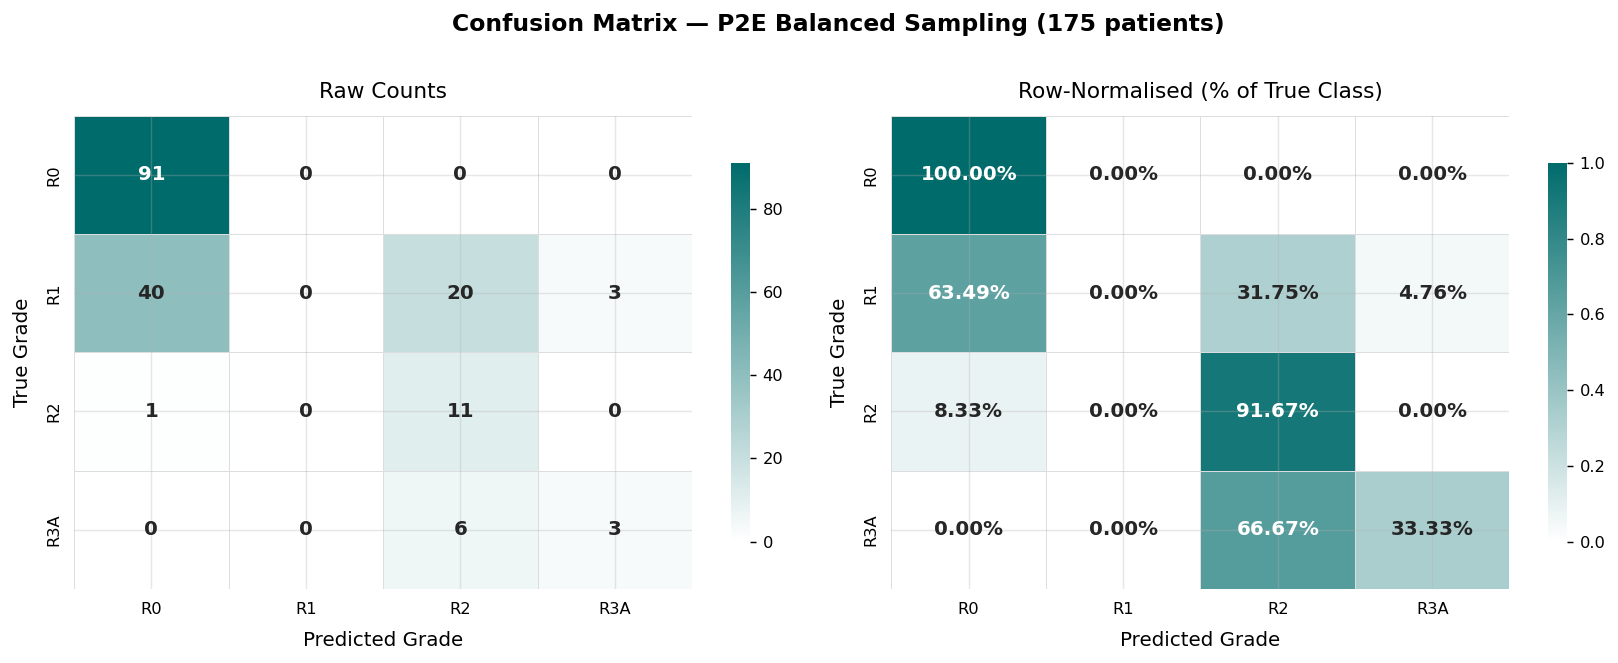

Saved figures/p2e_confusion_matrix.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — P2E Balanced Sampling (175 patients)',
             fontsize=13, fontweight='bold', y=1.01)

teal_cmap = LinearSegmentedColormap.from_list('tc', ['#FFFFFF', TEAL])
cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2%'],
    ['Raw Counts', 'Row-Normalised (% of True Class)']):
    sns.heatmap(data, ax=ax, annot=True, fmt=fmt, cmap=teal_cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='#DDD', cbar_kws={'shrink':0.8},
                annot_kws={'size':11,'weight':'bold'})
    ax.set_xlabel('Predicted Grade', labelpad=8)
    ax.set_ylabel('True Grade', labelpad=8)
    ax.set_title(title, pad=10)
    ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('figures/p2e_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/p2e_confusion_matrix.png')

## 5. ROC Curves

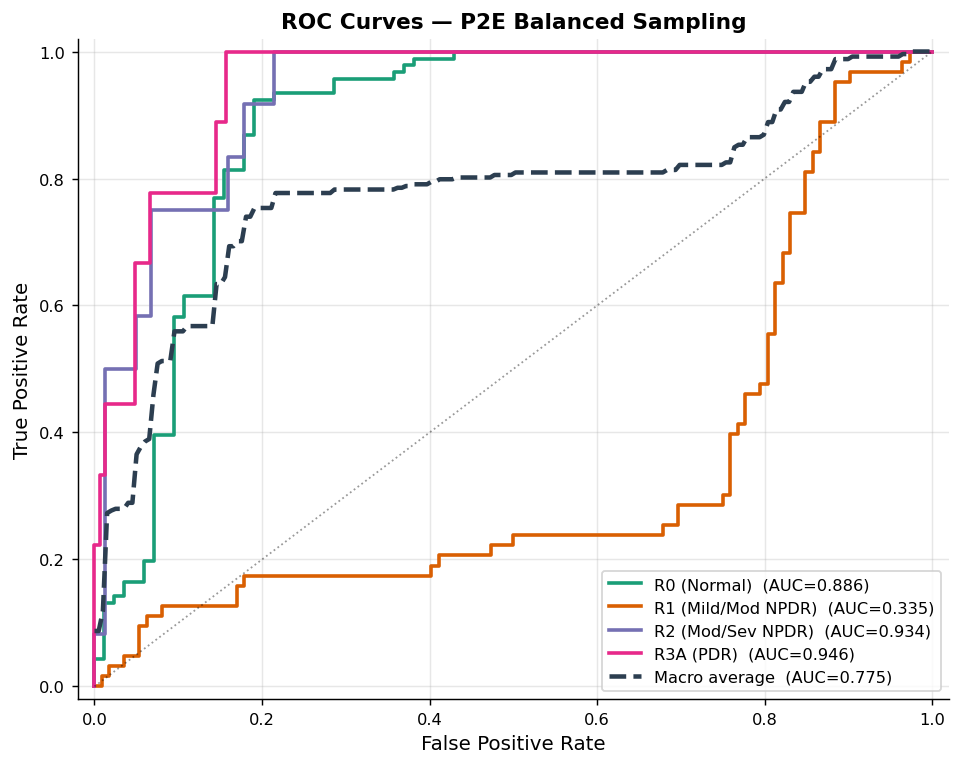

Saved figures/p2e_roc_curves.png


In [6]:
fig, ax = plt.subplots(figsize=(7.5, 6))

macro_tprs, mean_fpr = [], np.linspace(0, 1, 200)
for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    fpr, tpr, _ = roc_curve(pt_labels_bin[:,i], pt_probs[:,i])
    auc_i = roc_auc_score(pt_labels_bin[:,i], pt_probs[:,i])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{CLASS_LABELS[i]}  (AUC={auc_i:.3f})')
    macro_tprs.append(np.interp(mean_fpr, fpr, tpr))

macro_tpr = np.mean(macro_tprs, axis=0)
ax.plot(mean_fpr, macro_tpr, color='#2C3E50', lw=2.5, ls='--',
        label=f'Macro average  (AUC={auroc:.3f})')
ax.plot([0,1],[0,1],'k:',lw=1,alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — P2E Balanced Sampling', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)

plt.tight_layout()
plt.savefig('figures/p2e_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/p2e_roc_curves.png')

## 6. Sensitivity Comparison — P2E vs P2B+TTA

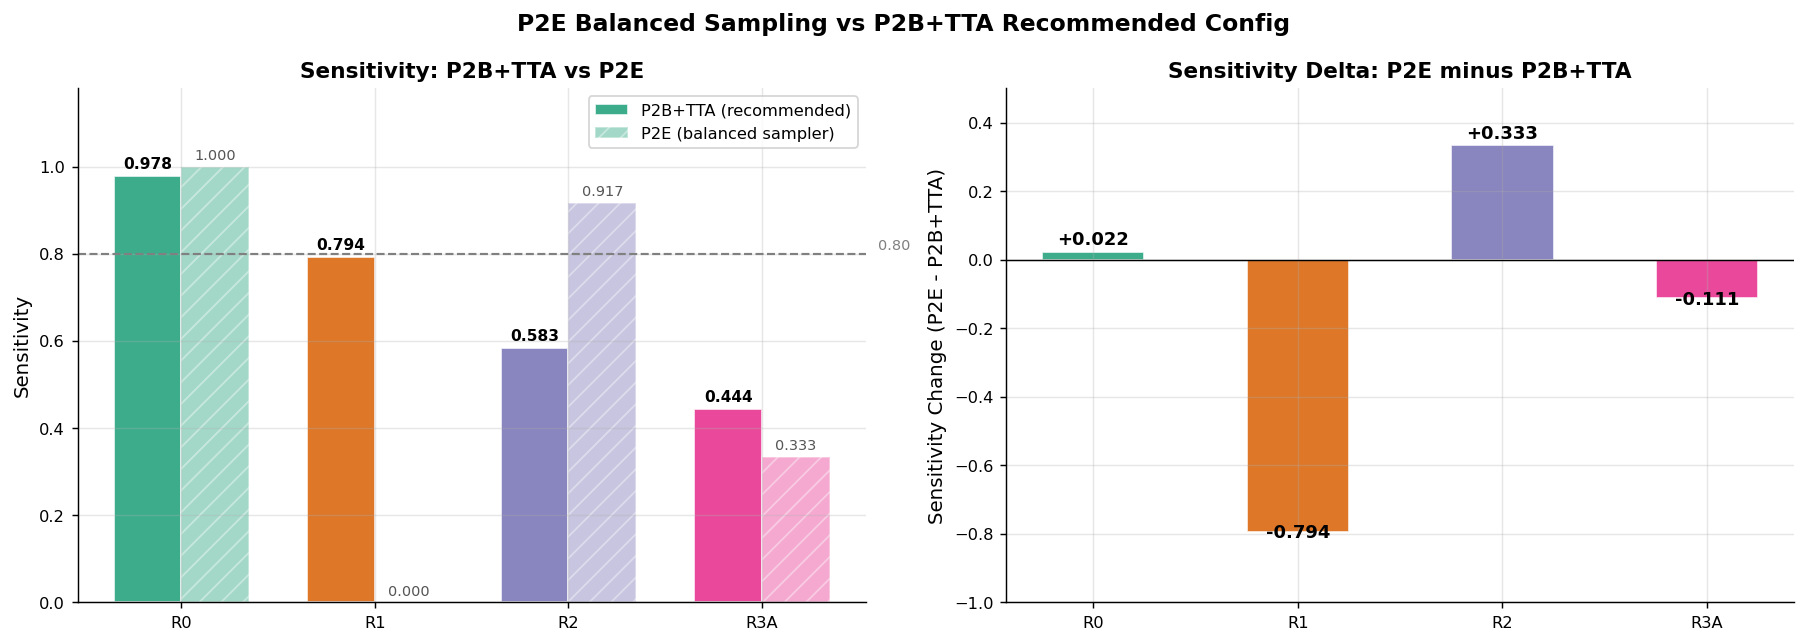

Saved figures/p2e_sensitivity_comparison.png


In [7]:
ref_sens = [0.9780, 0.7937, 0.5833, 0.4444]
p2e_sens = [per_class[i]['Sensitivity'] for i in range(4)]
ref_spec = [0.8690, 0.9018, 0.9816, 1.0000]
p2e_spec = [per_class[i]['Specificity'] for i in range(4)]

x, w = np.arange(4), 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sensitivity comparison
ax = axes[0]
b1 = ax.bar(x - w/2, ref_sens, w, label='P2B+TTA (recommended)',
            color=CLASS_COLORS, alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, p2e_sens, w, label='P2E (balanced sampler)',
            color=CLASS_COLORS, alpha=0.40, edgecolor='white', hatch='//')
ax.axhline(0.80, color='grey', ls='--', lw=1.2)
ax.text(3.6, 0.81, '0.80', fontsize=8, color='grey')
for bar, val in zip(b1, ref_sens):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(b2, p2e_sens):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#555')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.18); ax.set_ylabel('Sensitivity')
ax.set_title('Sensitivity: P2B+TTA vs P2E', fontweight='bold')
ax.legend(fontsize=9)

# Delta bar chart
ax2 = axes[1]
deltas = [p2e_sens[i] - ref_sens[i] for i in range(4)]
bar_colors = [CLASS_COLORS[i] for i in range(4)]
bars = ax2.bar(x, deltas, 0.5, color=bar_colors,
               alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
for bar, val in zip(bars, deltas):
    ypos = val + 0.01 if val >= 0 else val - 0.03
    ax2.text(bar.get_x()+bar.get_width()/2, ypos,
             f'{val:+.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylabel('Sensitivity Change (P2E - P2B+TTA)')
ax2.set_title('Sensitivity Delta: P2E minus P2B+TTA', fontweight='bold')
ax2.set_ylim(-1.0, 0.5)

fig.suptitle('P2E Balanced Sampling vs P2B+TTA Recommended Config',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p2e_sensitivity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/p2e_sensitivity_comparison.png')

## 7. Probability Distributions

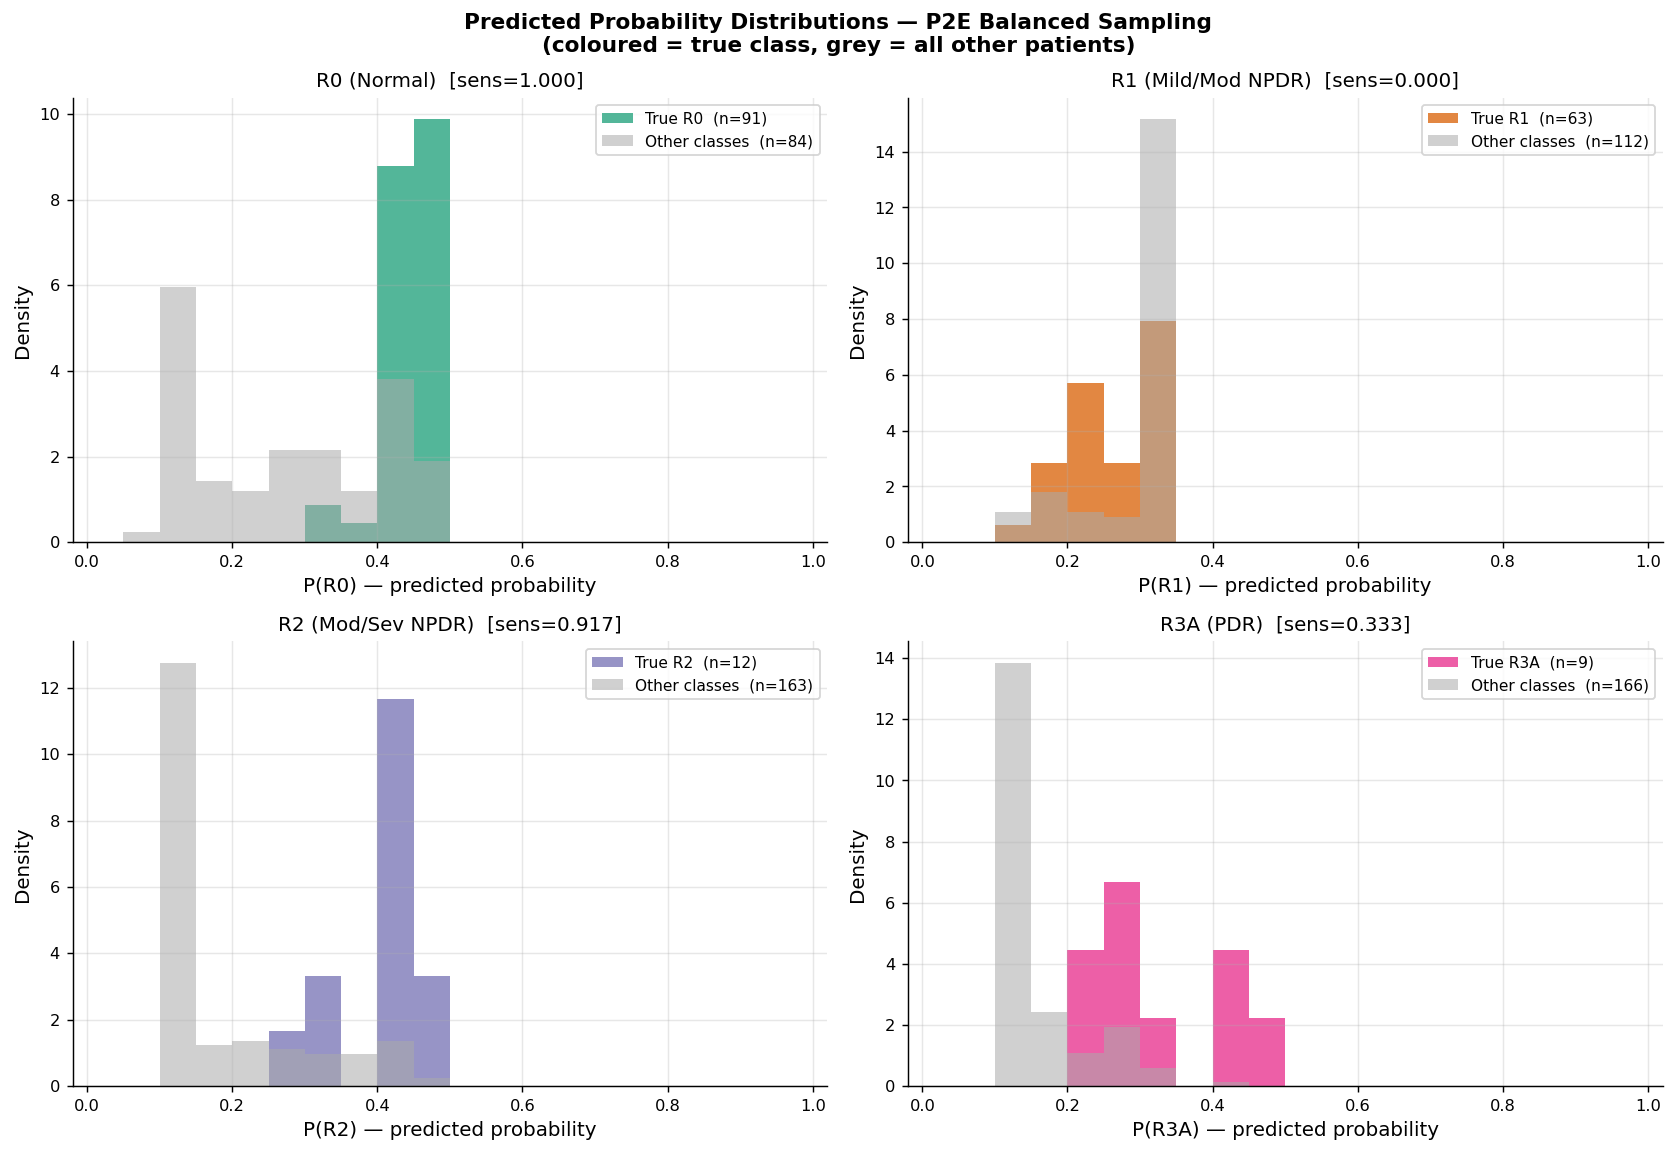

Saved figures/p2e_probability_distributions.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (cn, cl, color) in enumerate(zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS)):
    ax = axes[i]
    is_true = (pt_labels == i)
    ax.hist(pt_probs[is_true, i],  bins=20, range=(0,1), color=color,
            alpha=0.75, label=f'True {cn}  (n={is_true.sum()})', density=True)
    ax.hist(pt_probs[~is_true, i], bins=20, range=(0,1), color='#AAAAAA',
            alpha=0.55, label=f'Other classes  (n={(~is_true).sum()})', density=True)
    sens_val = per_class[i]['Sensitivity']
    ax.set_xlabel(f'P({cn}) — predicted probability')
    ax.set_ylabel('Density')
    ax.set_title(f'{cl}  [sens={sens_val:.3f}]', fontsize=11)
    ax.set_xlim(-0.02, 1.02)
    ax.legend(fontsize=8.5)

title_str = ('Predicted Probability Distributions — P2E Balanced Sampling\n'
             '(coloured = true class, grey = all other patients)')
fig.suptitle(title_str, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/p2e_probability_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/p2e_probability_distributions.png')

## 8. Classification Report

In [9]:
print(classification_report(pt_labels, pt_preds,
                            target_names=CLASS_LABELS, digits=4, zero_division=0))

                    precision    recall  f1-score   support

       R0 (Normal)     0.6894    1.0000    0.8161        91
R1 (Mild/Mod NPDR)     0.0000    0.0000    0.0000        63
 R2 (Mod/Sev NPDR)     0.2973    0.9167    0.4490        12
         R3A (PDR)     0.5000    0.3333    0.4000         9

          accuracy                         0.6000       175
         macro avg     0.3717    0.5625    0.4163       175
      weighted avg     0.4046    0.6000    0.4758       175



## 9. Summary Dashboard

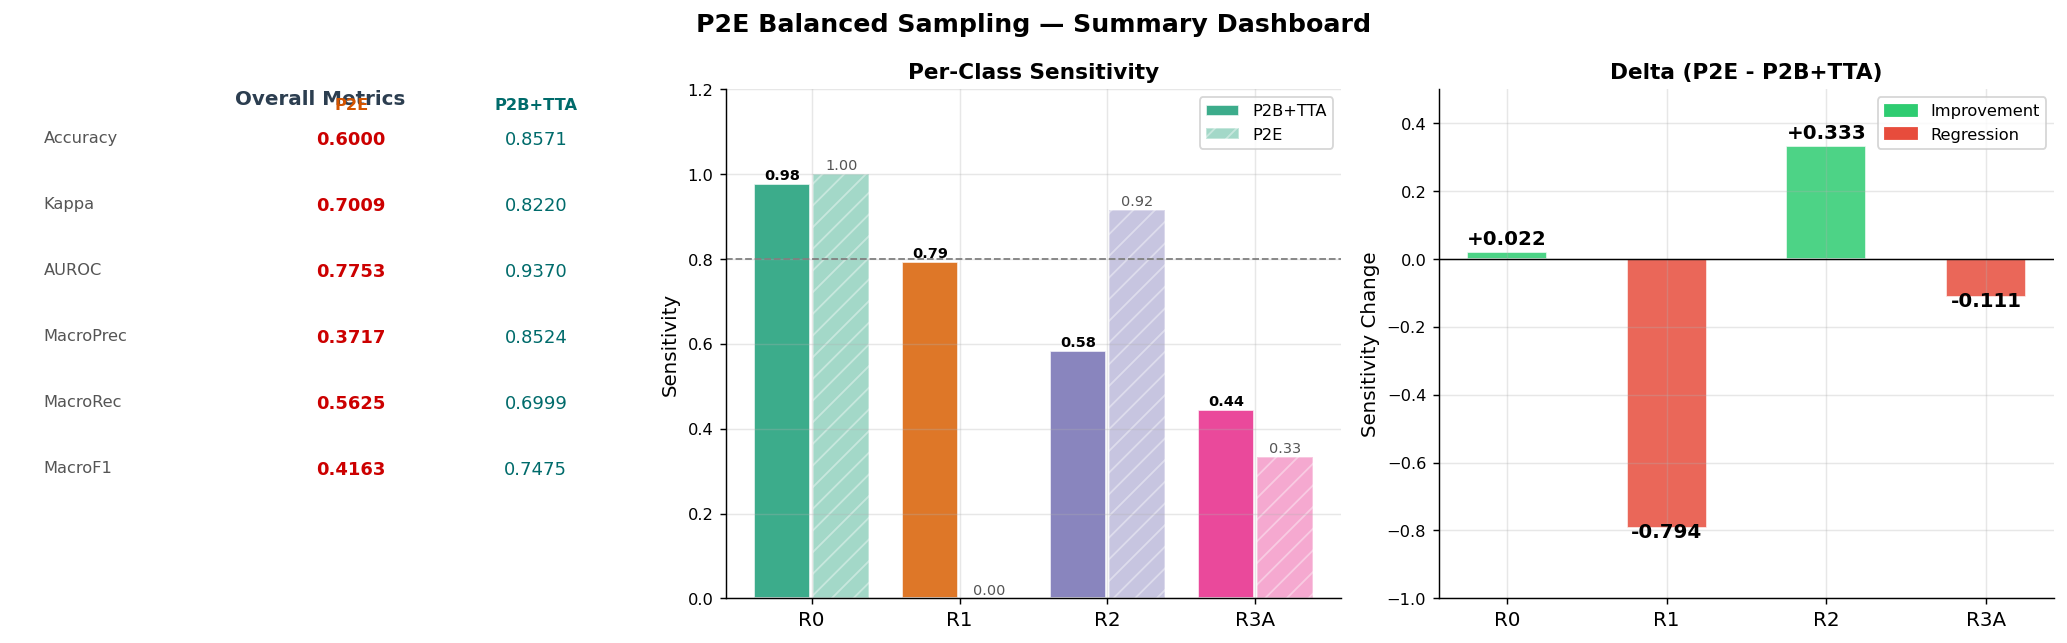

Saved figures/p2e_summary_dashboard.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('P2E Balanced Sampling — Summary Dashboard',
             fontsize=14, fontweight='bold')

# Panel 1: overall metrics table
ax1 = axes[0]; ax1.axis('off')
ref_vals = {'Accuracy':0.8571, 'Kappa':0.8220, 'AUROC':0.9370,
            'MacroPrec':0.8524, 'MacroRec':0.6999, 'MacroF1':0.7475}
p2e_vals = {'Accuracy':accuracy, 'Kappa':kappa, 'AUROC':auroc,
            'MacroPrec':macro_prec, 'MacroRec':macro_rec, 'MacroF1':macro_f1}
y0 = 0.92
ax1.text(0.5, 1.0, 'Overall Metrics', transform=ax1.transAxes,
         fontsize=11, fontweight='bold', ha='center', va='top', color='#2C3E50')
ax1.text(0.55, 0.96, 'P2E', transform=ax1.transAxes,
         fontsize=9, ha='center', color=AMBER, fontweight='bold')
ax1.text(0.85, 0.96, 'P2B+TTA', transform=ax1.transAxes,
         fontsize=9, ha='center', color=TEAL, fontweight='bold')
for label in ref_vals:
    p2e_v = p2e_vals[label]; ref_v = ref_vals[label]
    better = p2e_v >= ref_v
    ax1.text(0.05, y0, label, transform=ax1.transAxes,
             fontsize=9, color='#555', va='top')
    ax1.text(0.55, y0, f'{p2e_v:.4f}', transform=ax1.transAxes,
             fontsize=10, fontweight='bold', color=AMBER if better else '#CC0000',
             va='top', ha='center')
    ax1.text(0.85, y0, f'{ref_v:.4f}', transform=ax1.transAxes,
             fontsize=10, color=TEAL, va='top', ha='center')
    y0 -= 0.13

# Panel 2: per-class sensitivity bars
ax2 = axes[1]
x   = np.arange(4)
ax2.bar(x - 0.2, ref_sens, 0.38, color=CLASS_COLORS, alpha=0.85,
        label='P2B+TTA', edgecolor='white')
ax2.bar(x + 0.2, p2e_sens, 0.38, color=CLASS_COLORS, alpha=0.40,
        label='P2E', edgecolor='white', hatch='//')
ax2.axhline(0.80, color='grey', ls='--', lw=1)
for i, (rv, pv) in enumerate(zip(ref_sens, p2e_sens)):
    ax2.text(i-0.2, rv+0.01, f'{rv:.2f}', ha='center', fontsize=8, fontweight='bold')
    ax2.text(i+0.2, pv+0.01, f'{pv:.2f}', ha='center', fontsize=8, color='#555')
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES, fontsize=11)
ax2.set_ylim(0, 1.2); ax2.set_ylabel('Sensitivity')
ax2.set_title('Per-Class Sensitivity', fontweight='bold')
ax2.legend(fontsize=9)

# Panel 3: delta bars
ax3 = axes[2]
deltas = [p2e_sens[i] - ref_sens[i] for i in range(4)]
bar_clrs = ['#2ECC71' if d >= 0 else '#E74C3C' for d in deltas]
bars = ax3.bar(x, deltas, 0.5, color=bar_clrs, alpha=0.85, edgecolor='white')
ax3.axhline(0, color='black', lw=0.8)
for bar, val, cn in zip(bars, deltas, CLASS_NAMES):
    yp = val + 0.01 if val >= 0 else val - 0.04
    ax3.text(bar.get_x()+bar.get_width()/2, yp,
             f'{val:+.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(CLASS_NAMES, fontsize=11)
ax3.set_ylim(-1.0, 0.5)
ax3.set_ylabel('Sensitivity Change')
ax3.set_title('Delta (P2E - P2B+TTA)', fontweight='bold')
green_patch = mpatches.Patch(color='#2ECC71', label='Improvement')
red_patch   = mpatches.Patch(color='#E74C3C', label='Regression')
ax3.legend(handles=[green_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.savefig('figures/p2e_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/p2e_summary_dashboard.png')

## 10. Key Findings

### What the balanced sampler changed
WeightedRandomSampler boosted R2 and R3A images ~9–15× per epoch. The model responded by learning to fire heavily on those classes.

### Why R1 collapsed to 0.000
R1 sits between R0 and R2 on the severity scale. When the model is pushed to aggressively prefer R2, samples that are mildly abnormal (R1) get misclassified as R2 instead. This is a classic oversampling failure: boosting one minority class can cannibalise the adjacent class.

### Trade-off summary

| Class | P2B+TTA | P2E | Winner |
|---|---|---|---|
| R0 | 0.978 | 1.000 | P2E |
| R1 | 0.794 | 0.000 | **P2B+TTA** |
| R2 | 0.583 | 0.917 | P2E |
| R3A | 0.444 | 0.333 | P2B+TTA |
| AUROC | 0.937 | 0.775 | **P2B+TTA** |
| Kappa | 0.822 | 0.701 | **P2B+TTA** |

### Conclusion
P2E is not a viable replacement. However it demonstrates that R2 is learnable at high sensitivity — the problem is isolating that gain without destroying R1. Possible next directions:
- **Hybrid approach**: use the sampler *plus* a mild focal term to retain R1
- **Two-stage model**: first separate {R0,R1} from {R2,R3A}, then sub-classify
- **More R1/R2 data**: the real constraint is annotation scarcity